## Imports

In [1]:
%load_ext autoreload
%autoreload 2
import time

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from eci.adapter import SimulationAdapter
from eci.environment import Environment
from eci.visualizer import SimulationVisualizer
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic
from eci.voting_system.random_voting import _vote_random

## Parameter Configuration 
The simulation constants are defined here.

In [13]:
NUM_VOTERS = 200  # Number of voters
NUM_CANDIDATES = 6  # Number of candidates
NUM_PREFERENCES = 6  # Number of preferences per voter
NUM_SIMULATIONS = 100  # Number of simulation steps (trajectories)

## Environment Initialization 
The environment is created using the parameters defined above.

In [14]:
env = Environment(
    num_voters=NUM_VOTERS,
    num_candidates=NUM_CANDIDATES,
    num_preferences=NUM_PREFERENCES,
)
env.num_simulations = NUM_SIMULATIONS

## Preference Initialization 
The network structure connecting the agents (voters) is initialized.

In [34]:
# 1. Initialisation viz and adapter
viz = SimulationVisualizer()
adapter = SimulationAdapter()

/Users/sylvainestebe/Code/european-city-inference/src/eci/visualizer.py:39: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  DataFrame containing preference data.


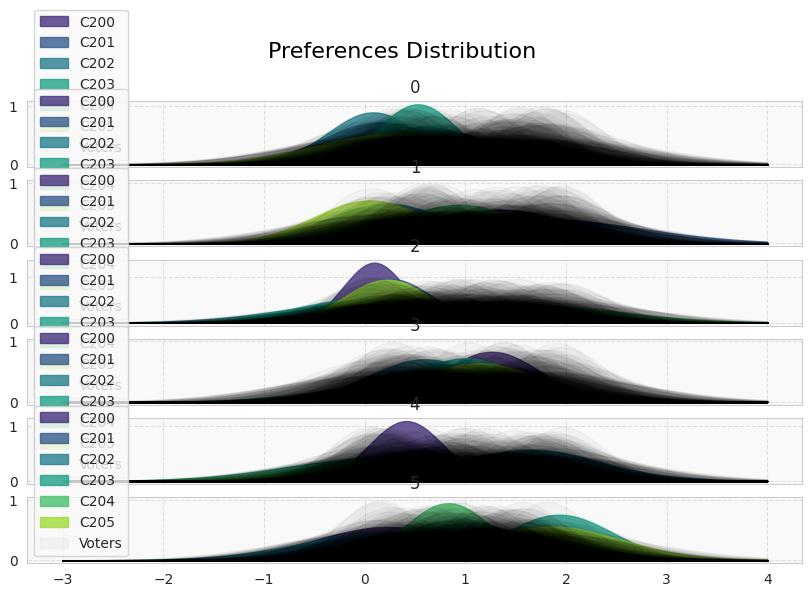

In [36]:
pref_data = adapter.prepare_preference_data(env)
fig, ax1 = viz.plot_preference_distributions(pref_data)
fig.suptitle("Preferences Distribution", fontsize=16)
# change size of the figure
plt.show()

## Running the Simulation

### Random voting

In [26]:
# run observation
env.initialize_network()
# intiatialize random key
key = jax.random.PRNGKey(42)
## run n simulations
sim = env.run_n_simulation(_vote_random, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

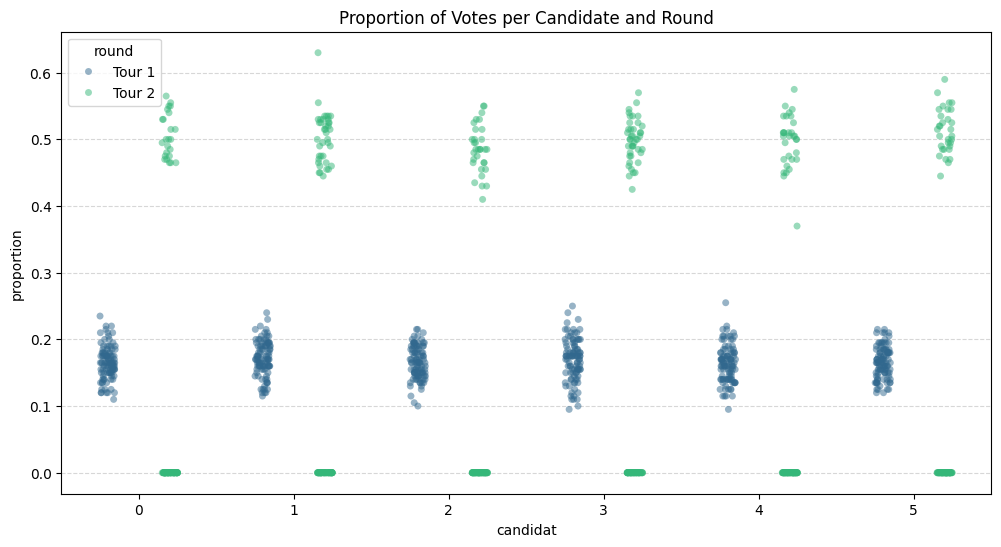

In [27]:
win = []
vote_1 = []
vote_2 = []

for i in range(NUM_SIMULATIONS):
    win.append(sim[i]["final_winner"])

for i in range(NUM_SIMULATIONS):
    vote_1.append(sim[i]["vote_round_1"])
    vote_2.append(sim[i]["vote_final_round_2"])

v1 = np.array(vote_1)
v2 = np.array(vote_2)
winners = np.array(win)
n_simulations, n_voters = v1.shape
all_candidates = np.unique(np.concatenate([v1, v2]))

data_list = []

for i in range(n_simulations):
    counts_1 = np.bincount(v1[i], minlength=len(all_candidates))
    props_1 = counts_1 / n_voters

    counts_2 = np.bincount(v2[i], minlength=len(all_candidates))
    props_2 = counts_2 / n_voters

    winner_of_sim = winners[i]

    for cand_id in all_candidates:
        is_winner = cand_id == winner_of_sim

        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_1[cand_id],
                "round": "Tour 1",
                "a_gagne_final": is_winner,
            }
        )

        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_2[cand_id],
                "round": "Tour 2",
                "a_gagne_final": is_winner,
            }
        )

df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x="candidat",
    y="proportion",
    hue="round",
    dodge=True,
    jitter=True,
    alpha=0.5,
    palette="viridis",
)

plt.title("Proportion of Votes per Candidate and Round")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Plurality voting

In [28]:
env.initialize_network()
# intiatialize random key
key = jax.random.PRNGKey(42)
## run n simulations
sim = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

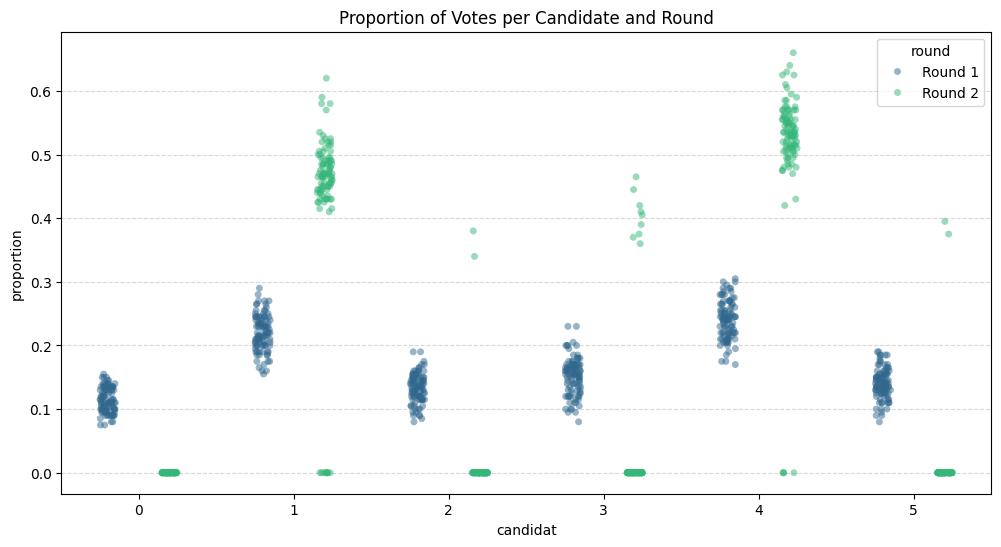

In [ ]:
win = []
vote_1 = []
vote_2 = []

for i in range(NUM_SIMULATIONS):
    win.append(sim[i]["final_winner"])

for i in range(NUM_SIMULATIONS):
    vote_1.append(sim[i]["vote_round_1"])
    vote_2.append(sim[i]["vote_final_round_2"])

v1 = np.array(vote_1)
v2 = np.array(vote_2)
winners = np.array(win)

n_simulations, n_voters = v1.shape
all_candidates = np.unique(np.concatenate([v1, v2]))

data_list = []

for i in range(n_simulations):
    counts_1 = np.bincount(v1[i], minlength=len(all_candidates))
    props_1 = counts_1 / n_voters

    counts_2 = np.bincount(v2[i], minlength=len(all_candidates))
    props_2 = counts_2 / n_voters

    winner_of_sim = winners[i]

    for cand_id in all_candidates:
        is_winner = cand_id == winner_of_sim

        # Ajout Tour 1
        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_1[cand_id],
                "round": "Round 1",
                "a_gagne_final": is_winner,
            }
        )

        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_2[cand_id],
                "round": "Round 2",
                "a_gagne_final": is_winner,
            }
        )

df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x="candidat",
    y="proportion",
    hue="round",
    dodge=True,
    jitter=True,
    alpha=0.5,
    palette="viridis",  # Couleurs distinctes
)

plt.title("Proportion of Votes per Candidate and Round")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

### Quadratic voting

In [30]:
env.initialize_network()

# intiatialize random key
key = jax.random.PRNGKey(int(time.time()))
## run n simulations
sim = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)
# update the agents with the results
env._update_agents()
# use result to create dataframe for plotting
env.df = env.create_data_frame()

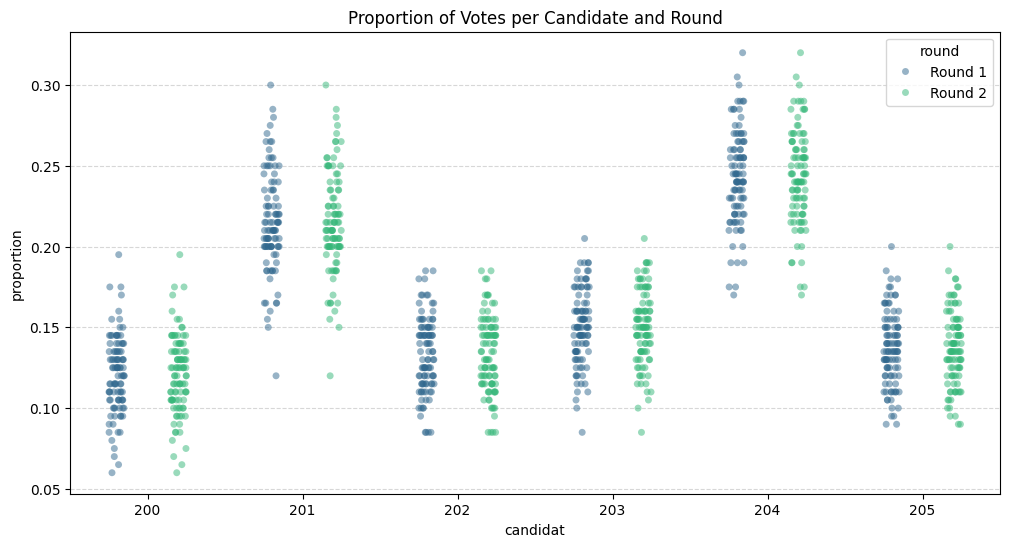

In [31]:
win = []
vote_1 = []
vote_2 = []

for i in range(NUM_SIMULATIONS):
    win.append(sim[i]["final_winner"])

for i in range(NUM_SIMULATIONS):
    vote_1.append(sim[i]["vote_round_1"])
    vote_2.append(sim[i]["vote_final_round_2"])

v1 = np.array(vote_1)
v2 = np.array(vote_2)
winners = np.array(win)
n_simulations, n_voters = v1.shape
all_candidates = np.unique(np.concatenate([v1, v2]))

data_list = []

for i in range(n_simulations):
    counts_1 = np.bincount(v1[i], minlength=len(all_candidates))
    props_1 = counts_1 / n_voters

    counts_2 = np.bincount(v2[i], minlength=len(all_candidates))
    props_2 = counts_2 / n_voters

    winner_of_sim = winners[i]

    for cand_id in all_candidates:
        is_winner = cand_id == winner_of_sim

        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_1[cand_id],
                "round": "Round 1",
                "a_gagne_final": is_winner,
            }
        )

        data_list.append(
            {
                "simulation": i,
                "candidat": cand_id,
                "proportion": props_2[cand_id],
                "round": "Round 2",
                "a_gagne_final": is_winner,
            }
        )

df = pd.DataFrame(data_list)

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df,
    x="candidat",
    y="proportion",
    hue="round",
    dodge=True,
    jitter=True,
    alpha=0.5,
    palette="viridis",  # Couleurs distinctes
)

plt.title("Proportion of Votes per Candidate and Round")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()